# Install and Import Required Libraries

In [2]:
!pip install scanpy scvi-tools shap scikit-learn matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import scanpy as sc
import scvi
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load and Preprocess Data 

In [4]:
import warnings
warnings.filterwarnings("ignore")


In [31]:
import scanpy as sc
import os

# Define directory containing .h5 files
data_dir = "/Users/mominaahsan/Desktop/Cell Bio/cellbio/data"
h5_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".h5")])
h5_files

['GSM4339769_C141_filtered_feature_bc_matrix.h5',
 'GSM4339770_C142_filtered_feature_bc_matrix.h5',
 'GSM4339771_C143_filtered_feature_bc_matrix.h5',
 'GSM4339772_C144_filtered_feature_bc_matrix.h5',
 'GSM4339773_C145_filtered_feature_bc_matrix.h5',
 'GSM4339774_C146_filtered_feature_bc_matrix.h5',
 'GSM4475048_C51_filtered_feature_bc_matrix.h5',
 'GSM4475049_C52_filtered_feature_bc_matrix.h5',
 'GSM4475050_C100_filtered_feature_bc_matrix.h5',
 'GSM4475051_C148_filtered_feature_bc_matrix.h5',
 'GSM4475052_C149_filtered_feature_bc_matrix.h5',
 'GSM4475053_C152_filtered_feature_bc_matrix.h5']

In [32]:
# Load first .h5 file (assuming 10x Genomics format)
adata = sc.read_10x_h5(os.path.join(data_dir, h5_files[0]))
adata.shape

(6249, 33539)

In [33]:
# Step 1: Load and inspect individual files
sample_shapes = {}
all_adatas = []

print("\n Raw Data Overview (Before Normalization)\n")
for file in h5_files:
    file_path = os.path.join(data_dir, file)

    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()

    # Save shape info for display
    num_cells, num_genes = adata.shape
    sample_shapes[file] = (num_cells, num_genes)
    print(f"{file}: {num_cells} cells × {num_genes} genes")

    # Add sample info to obs
    adata.obs["sample_id"] = file
    all_adatas.append(adata)



 Raw Data Overview (Before Normalization)

GSM4339769_C141_filtered_feature_bc_matrix.h5: 6249 cells × 33539 genes
GSM4339770_C142_filtered_feature_bc_matrix.h5: 10269 cells × 33539 genes
GSM4339771_C143_filtered_feature_bc_matrix.h5: 20857 cells × 33539 genes
GSM4339772_C144_filtered_feature_bc_matrix.h5: 3716 cells × 33539 genes
GSM4339773_C145_filtered_feature_bc_matrix.h5: 18044 cells × 33539 genes
GSM4339774_C146_filtered_feature_bc_matrix.h5: 4111 cells × 33539 genes
GSM4475048_C51_filtered_feature_bc_matrix.h5: 11115 cells × 33538 genes
GSM4475049_C52_filtered_feature_bc_matrix.h5: 10366 cells × 33538 genes
GSM4475050_C100_filtered_feature_bc_matrix.h5: 8972 cells × 33538 genes
GSM4475051_C148_filtered_feature_bc_matrix.h5: 3920 cells × 33539 genes
GSM4475052_C149_filtered_feature_bc_matrix.h5: 2879 cells × 33539 genes
GSM4475053_C152_filtered_feature_bc_matrix.h5: 7732 cells × 33539 genes


In [34]:
# Step 2: Combine all into a single AnnData
adata_combined = all_adatas[0].concatenate(
    *all_adatas[1:],
    batch_key="sample_batch",
    batch_categories=h5_files,
    index_unique=None  # Keep original cell barcodes
)
# Make sure gene names are unique across all batches
adata_combined.var_names_make_unique()

In [35]:
# Step 3: Summary of combined data
print("\n Combined AnnData Summary")
print(f"Total shape: {adata_combined.shape} (cells × genes)")
print(f"Samples combined: {adata_combined.obs['sample_id'].nunique()}")
print("Sample breakdown:")
print(adata_combined.obs['sample_id'].value_counts())


 Combined AnnData Summary
Total shape: (108230, 33538) (cells × genes)
Samples combined: 12
Sample breakdown:
sample_id
GSM4339771_C143_filtered_feature_bc_matrix.h5    20857
GSM4339773_C145_filtered_feature_bc_matrix.h5    18044
GSM4475048_C51_filtered_feature_bc_matrix.h5     11115
GSM4475049_C52_filtered_feature_bc_matrix.h5     10366
GSM4339770_C142_filtered_feature_bc_matrix.h5    10269
GSM4475050_C100_filtered_feature_bc_matrix.h5     8972
GSM4475053_C152_filtered_feature_bc_matrix.h5     7732
GSM4339769_C141_filtered_feature_bc_matrix.h5     6249
GSM4339774_C146_filtered_feature_bc_matrix.h5     4111
GSM4475051_C148_filtered_feature_bc_matrix.h5     3920
GSM4339772_C144_filtered_feature_bc_matrix.h5     3716
GSM4475052_C149_filtered_feature_bc_matrix.h5     2879
Name: count, dtype: int64


In [36]:
# Optional: peek at gene names and obs info
print("\n First few genes:", adata_combined.var_names[:5].tolist())
print(" Metadata columns:", adata_combined.obs.columns.tolist())


 First few genes: ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3']
 Metadata columns: ['sample_id', 'sample_batch']


# Basic pre processing

In [37]:
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

adata_combined.obs['n_counts'] = adata_combined.X.sum(axis=1).A1
adata_combined.obs['n_genes'] = (adata_combined.X > 0).sum(axis=1).A1

In [39]:
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

print(" After Filtering and Normalization:", adata_combined.shape)
adata_combined.obs

 After Filtering and Normalization: (90695, 25626)


,sample_id,sample_batch,n_genes,n_counts
AAACCTGAGATGTCGG-1,GSM4339769_C141_filtered_feature_bc_matrix.h5,GSM4339769_C141_filtered_feature_bc_matrix.h5,1595,3732.0
AAACCTGAGGCTCATT-1,GSM4339769_C141_filtered_feature_bc_matrix.h5,GSM4339769_C141_filtered_feature_bc_matrix.h5,5276,33342.0
AAACCTGCAATCCGAT-1,GSM4339769_C141_filtered_feature_bc_matrix.h5,GSM4339769_C141_filtered_feature_bc_matrix.h5,1789,5727.0
AAACCTGCATGGTCAT-1,GSM4339769_C141_filtered_feature_bc_matrix.h5,GSM4339769_C141_filtered_feature_bc_matrix.h5,2004,4398.0
AAACCTGGTTTAGCTG-1,GSM4339769_C141_filtered_feature_bc_matrix.h5,GSM4339769_C141_filtered_feature_bc_matrix.h5,1451,3219.0
...,...,...,...,...
TTTGTCATCACGCATA-1,GSM4475053_C152_filtered_feature_bc_matrix.h5,GSM4475053_C152_filtered_feature_bc_matrix.h5,1021,1768.0
TTTGTCATCAGAAATG-1,GSM4475053_C152_filtered_feature_bc_matrix.h5,GSM4475053_C152_filtered_feature_bc_matrix.h5,3377,16389.0
TTTGTCATCAGTCCCT-1,GSM4475053_C152_filtered_feature_bc_matrix.h5,GSM4475053_C152_filtered_feature_bc_matrix.h5,1027,2993.0
TTTGTCATCATCGCTC-1,GSM4475053_C152_filtered_feature_bc_matrix.h5,GSM4475053_C152_filtered_feature_bc_matrix.h5,472,795.0


#  Highly Variable Genes (HVG selection) 

In [40]:

sc.pp.highly_variable_genes(adata_combined, n_top_genes=2000, subset=True)
print(f" After HVG Selection: {adata_combined.shape}")
adata_combined.var.head()

 After HVG Selection: (90695, 2000)


,gene_ids,feature_types,genome-GSM4339769_C141_filtered_feature_bc_matrix.h5,genome-GSM4339770_C142_filtered_feature_bc_matrix.h5,genome-GSM4339771_C143_filtered_feature_bc_matrix.h5,genome-GSM4339772_C144_filtered_feature_bc_matrix.h5,genome-GSM4339773_C145_filtered_feature_bc_matrix.h5,genome-GSM4339774_C146_filtered_feature_bc_matrix.h5,genome-GSM4475048_C51_filtered_feature_bc_matrix.h5,genome-GSM4475049_C52_filtered_feature_bc_matrix.h5,genome-GSM4475050_C100_filtered_feature_bc_matrix.h5,genome-GSM4475051_C148_filtered_feature_bc_matrix.h5,genome-GSM4475052_C149_filtered_feature_bc_matrix.h5,genome-GSM4475053_C152_filtered_feature_bc_matrix.h5,n_cells,highly_variable,means,dispersions,dispersions_norm
AL627309.3,ENSG00000239945,Gene Expression,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38,GRCh38,GRCh38,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,19,True,0.001273,3.101225,1.821737
AL732372.1,ENSG00000236601,Gene Expression,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38,GRCh38,GRCh38,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,6,True,0.000461,2.776624,1.206172
HES4,ENSG00000188290,Gene Expression,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38,GRCh38,GRCh38,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,18858,True,1.179331,2.943064,4.821619
ISG15,ENSG00000187608,Gene Expression,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38,GRCh38,GRCh38,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,70589,True,2.642188,2.490326,1.901555
AL645608.2,ENSG00000224969,Gene Expression,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,GRCh38,GRCh38,GRCh38,GRCh38_nCoV,GRCh38_nCoV,GRCh38_nCoV,689,True,0.081128,3.080433,1.782307


# Setup and Train scVI 

In [41]:

scvi.model.SCVI.setup_anndata(adata_combined)
vae = scvi.model.SCVI(adata_combined)
vae.train()
adata_combined.obsm['X_scVI'] = vae.get_latent_representation()
print("scVI latent space shape:", adata_combined.obsm['X_scVI'].shape)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 88/88: 100%|██████████| 88/88 [07:47<00:00,  5.14s/it, v_num=1, train_loss_step=333, train_loss_epoch=340]

`Trainer.fit` stopped: `max_epochs=88` reached.


Epoch 88/88: 100%|██████████| 88/88 [07:47<00:00,  5.31s/it, v_num=1, train_loss_step=333, train_loss_epoch=340]
scVI latent space shape: (90695, 10)


# Split Data 

In [44]:
test_files = [
    "GSM4475048_C51_filtered_feature_bc_matrix.h5",  # Healthy
    "GSM4339769_C141_filtered_feature_bc_matrix.h5", # Mild
    "GSM4339773_C145_filtered_feature_bc_matrix.h5"   # Severe
]

In [45]:
adata_test = adata_combined[adata_combined.obs["sample_id"].isin(test_files)].copy()
adata_train = adata_combined[~adata_combined.obs["sample_id"].isin(test_files)].copy()

print(f" Train set: {adata_train.n_obs} cells × {adata_train.n_vars} genes")
print(f" Test set: {adata_test.n_obs} cells × {adata_test.n_vars} genes")


 Train set: 57954 cells × 2000 genes
 Test set: 32741 cells × 2000 genes


# Visualizations: Genes per Cell and Sample Count

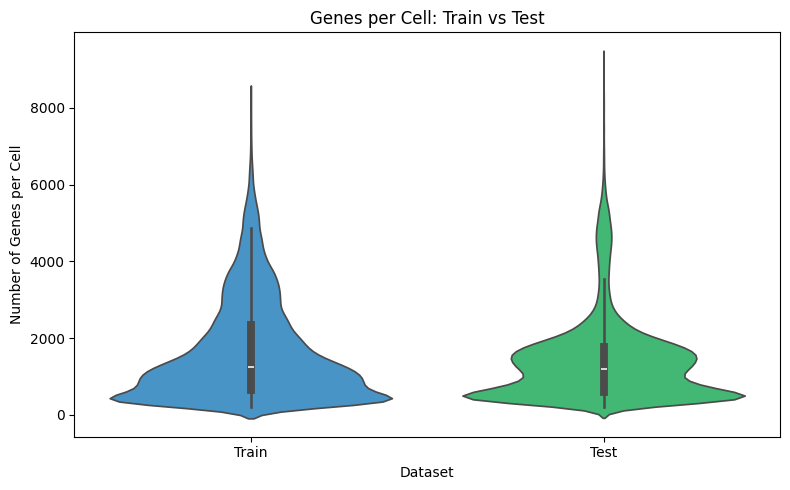

In [46]:
train_gene_counts = adata_train.obs['n_genes']
test_gene_counts = adata_test.obs['n_genes']

# Violin plot
df_violin = pd.DataFrame({
    'Genes per Cell': list(train_gene_counts) + list(test_gene_counts),
    'Dataset': ['Train'] * len(train_gene_counts) + ['Test'] * len(test_gene_counts)
})

plt.figure(figsize=(8,5))
sns.violinplot(x='Dataset', y='Genes per Cell', data=df_violin, palette=['#3498db', '#2ecc71'])
plt.ylabel('Number of Genes per Cell')
plt.title('Genes per Cell: Train vs Test')
plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

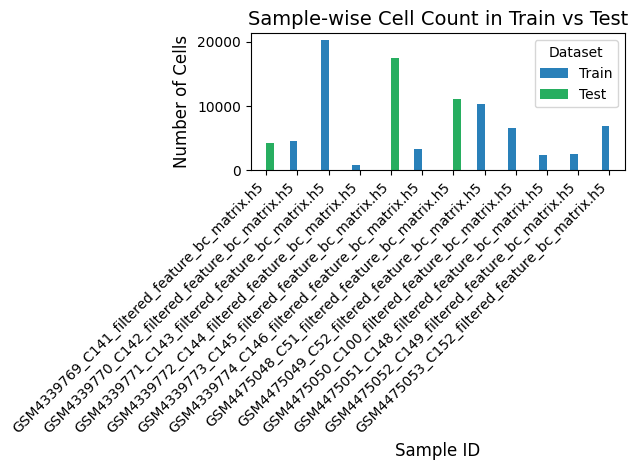

In [47]:
# Sample count bar plot
train_counts = adata_train.obs['sample_id'].value_counts()
test_counts = adata_test.obs['sample_id'].value_counts()
sample_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)

plt.figure(figsize=(12, 6))
sample_df.plot(kind='bar', color=['#2980b9', '#27ae60'])
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel("Sample ID", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.title("Sample-wise Cell Count in Train vs Test", fontsize=14)
plt.legend(title="Dataset", fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

# Attach true labels 

In [48]:

sample_to_label = {
    "GSM4339769": "mild",
    "GSM4339770": "mild",
    "GSM4339771": "severe",
    "GSM4339772": "mild",
    "GSM4339773": "severe",
    "GSM4339774": "severe",
    "GSM4475048": "healthy",
    "GSM4475049": "healthy",
    "GSM4475050": "healthy",
    "GSM4475051": "severe",
    "GSM4475052": "severe",
    "GSM4475053": "severe",
}

adata_train.obs['label'] = adata_train.obs['sample_id'].map(lambda x: sample_to_label.get(x.split("_")[0], "unknown"))
adata_test.obs['label'] = adata_test.obs['sample_id'].map(lambda x: sample_to_label.get(x.split("_")[0], "unknown"))

print("Train set label distribution:\n", adata_train.obs['label'].value_counts())
print("Test set label distribution:\n", adata_test.obs['label'].value_counts())


Train set label distribution:
 label
severe     35533
healthy    16944
mild        5477
Name: count, dtype: int64
Test set label distribution:
 label
severe     17396
healthy    11112
mild        4233
Name: count, dtype: int64


# Train Multiple Classifiers 

In [20]:
!pip install catboost


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [49]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

In [50]:
# Features and labels
X_train = adata_train.obsm['X_scVI']
X_test = adata_test.obsm['X_scVI']
y_train = adata_train.obs['label']
y_test = adata_test.obs['label']

# SVM model
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced')
print("▶ Training SVM...")
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# Evaluation
svm_acc = accuracy_score(y_test, svm_preds)
print(f"✅ SVM Accuracy: {svm_acc:.2f}")
print(classification_report(y_test, svm_preds))

▶ Training SVM...
✅ SVM Accuracy: 0.94
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     11112
        mild       0.68      0.97      0.80      4233
      severe       0.99      0.89      0.94     17396

    accuracy                           0.94     32741
   macro avg       0.89      0.95      0.91     32741
weighted avg       0.95      0.94      0.94     32741



In [54]:
# KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
print("▶ Training KNN...")
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

# Evaluation
knn_acc = accuracy_score(y_test, knn_preds)
print(f"✅ KNN Accuracy: {knn_acc:.2f}")
print(classification_report(y_test, knn_preds))

▶ Training KNN...
✅ KNN Accuracy: 0.97
              precision    recall  f1-score   support

     healthy       0.99      0.99      0.99     11112
        mild       0.89      0.90      0.89      4233
      severe       0.98      0.97      0.97     17396

    accuracy                           0.97     32741
   macro avg       0.95      0.96      0.95     32741
weighted avg       0.97      0.97      0.97     32741



In [55]:
# Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
print("▶ Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluation
rf_acc = accuracy_score(y_test, rf_preds)
print(f"✅ Random Forest Accuracy: {rf_acc:.2f}")
print(classification_report(y_test, rf_preds))

▶ Training Random Forest...
✅ Random Forest Accuracy: 0.96
              precision    recall  f1-score   support

     healthy       0.99      0.98      0.98     11112
        mild       0.88      0.87      0.87      4233
      severe       0.97      0.98      0.97     17396

    accuracy                           0.96     32741
   macro avg       0.95      0.94      0.94     32741
weighted avg       0.96      0.96      0.96     32741



In [56]:
# CatBoost model
cat_model = CatBoostClassifier(loss_function='MultiClass', verbose=0)
print("▶ Training CatBoost...")
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)

# Evaluation
cat_acc = accuracy_score(y_test, cat_preds)
print(f"✅ CatBoost Accuracy: {cat_acc:.2f}")
print(classification_report(y_test, cat_preds))

▶ Training CatBoost...
✅ CatBoost Accuracy: 0.97
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     11112
        mild       0.88      0.92      0.90      4233
      severe       0.98      0.97      0.98     17396

    accuracy                           0.97     32741
   macro avg       0.95      0.96      0.96     32741
weighted avg       0.97      0.97      0.97     32741



# Patient level 

In [57]:
from collections import Counter

# Patient-level majority voting using SVM predictions
svm_patient_preds_df = pd.DataFrame({
    'sample_id': adata_test.obs['sample_id'],
    'predicted_label': svm_preds
})

# Majority voting
svm_patient_preds = svm_patient_preds_df.groupby('sample_id')['predicted_label'].agg(lambda x: Counter(x).most_common(1)[0][0])

# True labels
svm_true_labels = adata_test.obs.groupby('sample_id')['label'].first()

# Calculate patient-level accuracy
svm_patient_acc = (svm_patient_preds == svm_true_labels).mean()
print(f"🏥 SVM Patient-Level Accuracy: {svm_patient_acc:.2f}")

🏥 SVM Patient-Level Accuracy: 1.00


In [58]:
# Patient-level majority voting using KNN predictions
knn_patient_preds_df = pd.DataFrame({
    'sample_id': adata_test.obs['sample_id'],
    'predicted_label': knn_preds
})

# Majority voting
knn_patient_preds = knn_patient_preds_df.groupby('sample_id')['predicted_label'].agg(lambda x: Counter(x).most_common(1)[0][0])

# True labels
knn_true_labels = adata_test.obs.groupby('sample_id')['label'].first()

# Calculate patient-level accuracy
knn_patient_acc = (knn_patient_preds == knn_true_labels).mean()
print(f"🏥 KNN Patient-Level Accuracy: {knn_patient_acc:.2f}")

🏥 KNN Patient-Level Accuracy: 1.00


In [59]:
# Patient-level majority voting using Random Forest predictions
rf_patient_preds_df = pd.DataFrame({
    'sample_id': adata_test.obs['sample_id'],
    'predicted_label': rf_preds
})

# Majority voting
rf_patient_preds = rf_patient_preds_df.groupby('sample_id')['predicted_label'].agg(lambda x: Counter(x).most_common(1)[0][0])

# True labels
rf_true_labels = adata_test.obs.groupby('sample_id')['label'].first()

# Calculate patient-level accuracy
rf_patient_acc = (rf_patient_preds == rf_true_labels).mean()
print(f"🏥 Random Forest Patient-Level Accuracy: {rf_patient_acc:.2f}")

🏥 Random Forest Patient-Level Accuracy: 1.00


In [60]:
# Patient-level majority voting using CatBoost predictions

# Make sure cat_preds is 1D
cat_preds = cat_preds.flatten()

cat_patient_preds_df = pd.DataFrame({
    'sample_id': adata_test.obs['sample_id'],
    'predicted_label': cat_preds
})

# Majority voting
cat_patient_preds = cat_patient_preds_df.groupby('sample_id')['predicted_label'].agg(lambda x: Counter(x).most_common(1)[0][0])

# True labels
cat_true_labels = adata_test.obs.groupby('sample_id')['label'].first()

# Calculate patient-level accuracy
cat_patient_acc = (cat_patient_preds == cat_true_labels).mean()
print(f"🏥 CatBoost Patient-Level Accuracy: {cat_patient_acc:.2f}")

🏥 CatBoost Patient-Level Accuracy: 1.00


# Explanability

In [61]:
import shap
import numpy as np
import pandas as pd



## SVM

In [62]:

np.random.seed(42)

X_train_df = pd.DataFrame(X_train, columns=[f'Latent_{i}' for i in range(X_train.shape[1])])
X_test_df  = pd.DataFrame(X_test , columns=[f'Latent_{i}' for i in range(X_test.shape[1])])

# Background + points-to-explain
background  = X_train_df.sample(min(100, len(X_train_df)), random_state=42)
X_explain   = X_test_df.sample(50, random_state=42)         

# Unified SHAP explainer (auto-selects Kernel for SVM)
explainer = shap.Explainer(svm_model.predict_proba, background)
sv_all    = explainer(X_explain)       



ExactExplainer explainer: 51it [07:51,  9.44s/it]                        


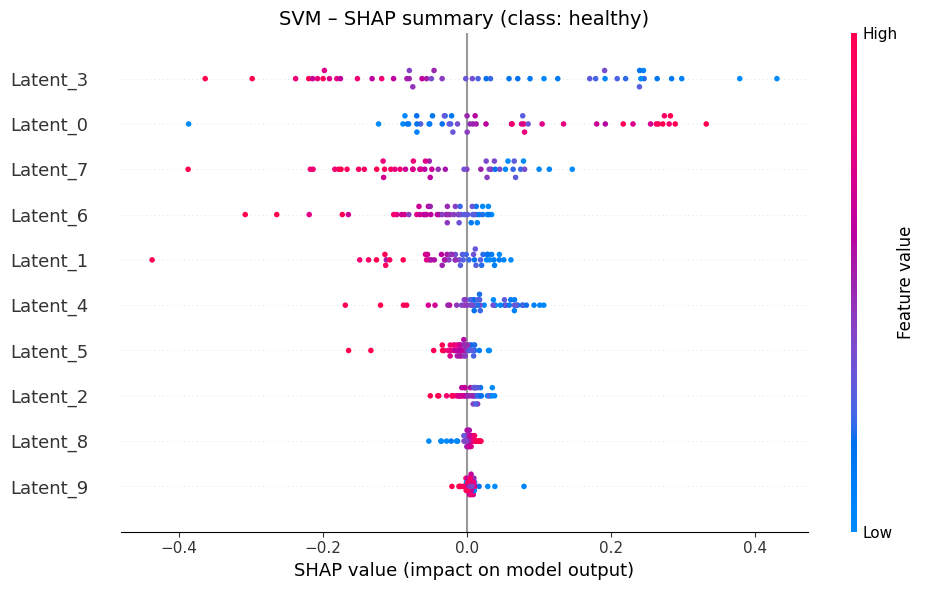

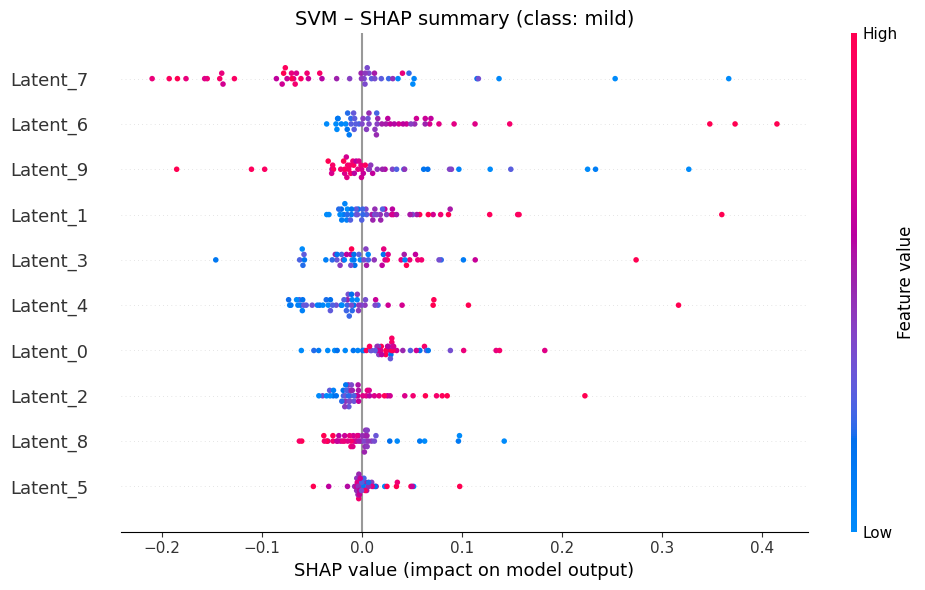

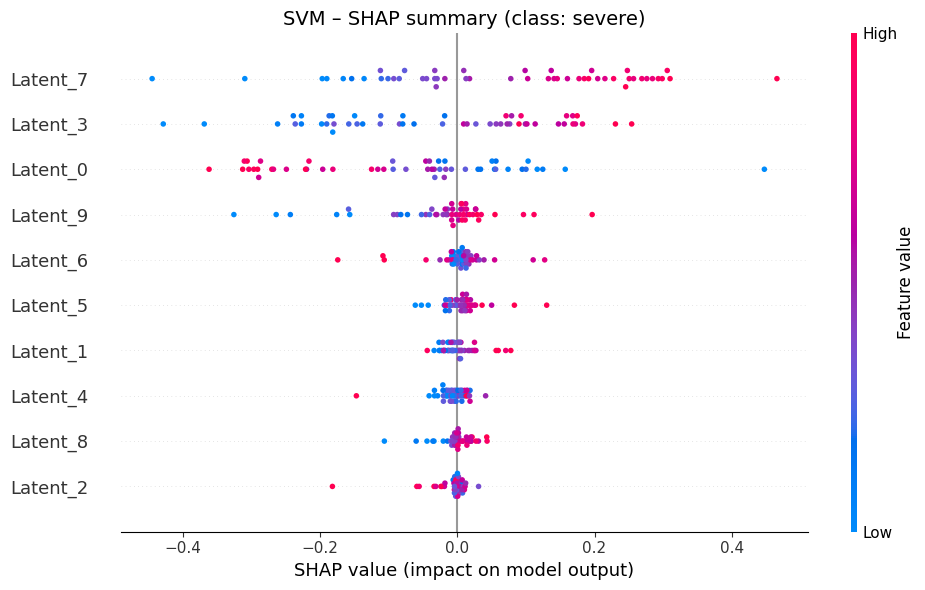

In [63]:
# Plotting SHAP values for each class
for c, cname in enumerate(svm_model.classes_):
    shap.plots.beeswarm(
        sv_all[:, :, c],
        max_display = 20,
        color_bar   = True,
        show        = False,            # keep control of the figure
        plot_size   = (10, 6)
    )
    plt.title(f'SVM – SHAP summary (class: {cname})', fontsize=14)
    plt.tight_layout()
    plt.show()

## KNN

In [94]:
# Unified SHAP explainer (auto-selects Kernel for Ranfom Forest)
explainer = shap.Explainer(knn_model.predict_proba, background)
knn_all    = explainer(X_explain)     

ExactExplainer explainer: 51it [05:56,  7.27s/it]                        


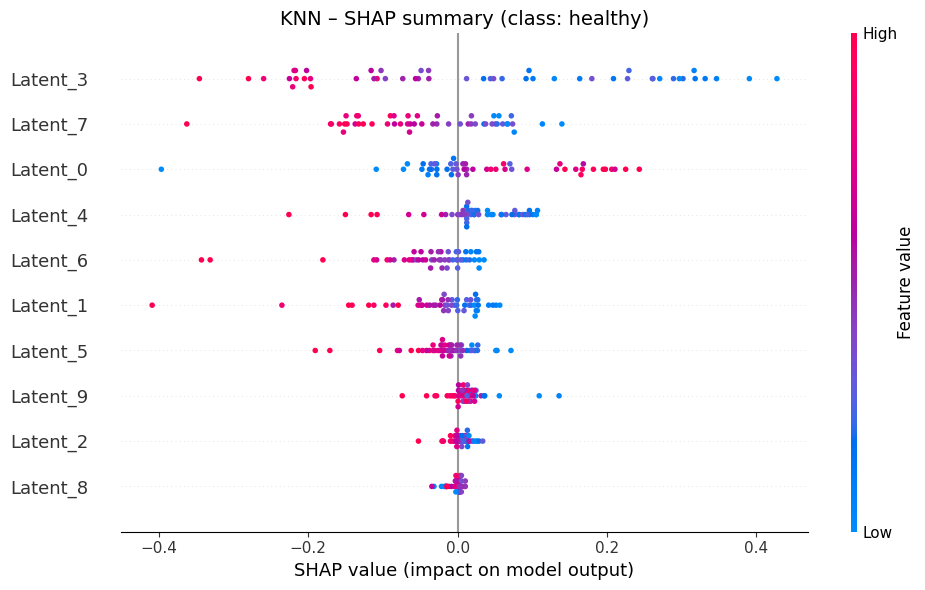

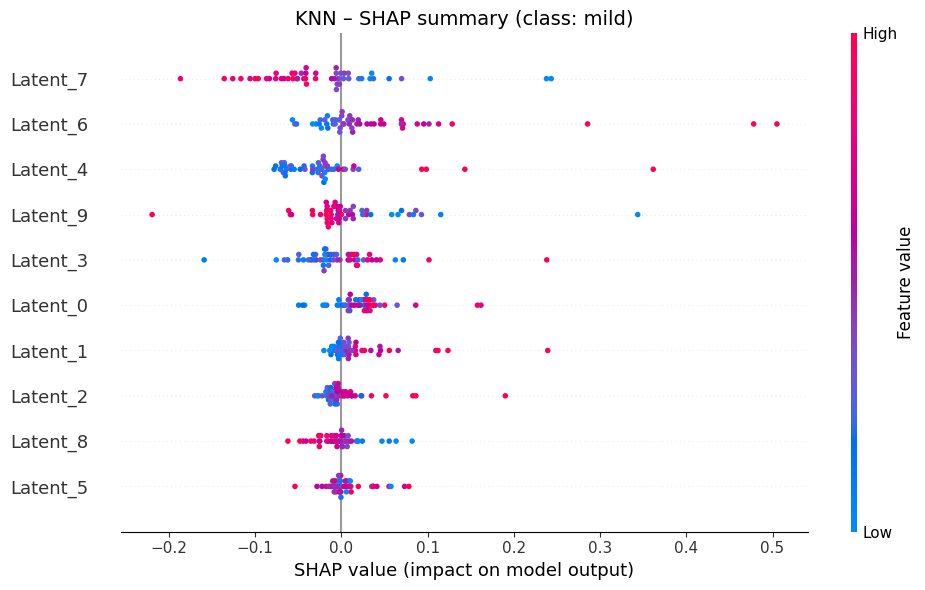

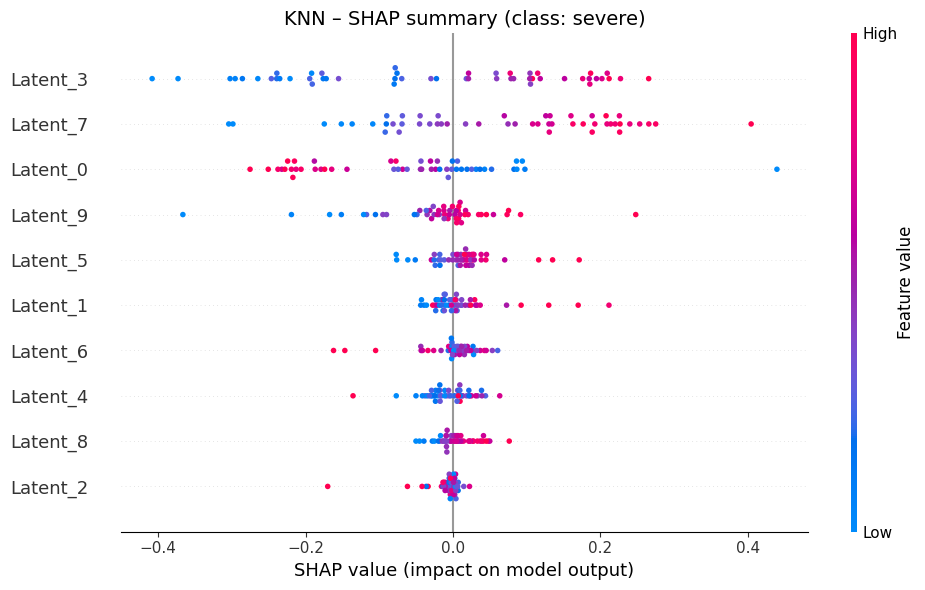

In [75]:
# Plotting SHAP values for each class 
for c, cname in enumerate(knn_model.classes_):
    shap.plots.beeswarm(
        knn_all[:, :, c],
        max_display = 20,
        color_bar   = True,
        show        = False,            # keep control of the figure
        plot_size   = (10, 6)
    )
    plt.title(f'KNN – SHAP summary (class: {cname})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Biomarkers 

## KNN

In [78]:


# Number of top features you want to select
TOP_N = 10

top_features_knn = {}

# For each class
for c, cname in enumerate(knn_model.classes_):
    # Average absolute SHAP values across samples
    shap_mean = np.abs(knn_all[:,:,c].values).mean(axis=0)
    
    # Create DataFrame
    shap_df = pd.DataFrame({
        'feature': X_explain.columns,
        'mean_abs_shap': shap_mean
    }).sort_values(by='mean_abs_shap', ascending=False)
    
    # Take Top N
    top_features_knn[cname] = shap_df.head(TOP_N)

print("✅ Extracted top Random Forest features per class!")


✅ Extracted top Random Forest features per class!


In [79]:
# Display top features for each class
for c, cname in enumerate(rf_model.classes_):
    print(f"\nTop {TOP_N} features for class '{cname}':")
    print(top_features_knn[cname])
# Save top features to CSV
top_features_df = pd.concat(top_features_knn, axis=0)
top_features_df.to_csv("top_features_knn.csv", index=False)
print("✅ Top features saved to 'top_features_knn.csv'!")


Top 10 features for class 'healthy':
    feature  mean_abs_shap
3  Latent_3       0.183978
7  Latent_7       0.085290
0  Latent_0       0.082915
4  Latent_4       0.053419
6  Latent_6       0.049527
1  Latent_1       0.048519
5  Latent_5       0.032269
9  Latent_9       0.020635
2  Latent_2       0.011277
8  Latent_8       0.006566

Top 10 features for class 'mild':
    feature  mean_abs_shap
7  Latent_7       0.058048
6  Latent_6       0.057107
4  Latent_4       0.046987
9  Latent_9       0.038041
3  Latent_3       0.035486
0  Latent_0       0.030486
1  Latent_1       0.024141
2  Latent_2       0.018916
8  Latent_8       0.018291
5  Latent_5       0.015562

Top 10 features for class 'severe':
    feature  mean_abs_shap
3  Latent_3       0.161375
7  Latent_7       0.142351
0  Latent_0       0.107772
9  Latent_9       0.053470
5  Latent_5       0.031347
1  Latent_1       0.028480
6  Latent_6       0.024932
4  Latent_4       0.024478
8  Latent_8       0.019600
2  Latent_2       0.012087

## SVM

In [68]:
# Number of top features you want to select 
TOP_N = 10
top_features_svm = {}
# For each class
for c, cname in enumerate(svm_model.classes_):
    # Average absolute SHAP values across samples
    shap_mean = np.abs(sv_all[:,:,c].values).mean(axis=0)
    
    # Create DataFrame
    shap_df = pd.DataFrame({
        'feature': X_explain.columns,
        'mean_abs_shap': shap_mean
    }).sort_values(by='mean_abs_shap', ascending=False)
    
    # Take Top N
    top_features_svm[cname] = shap_df.head(TOP_N)
print("✅ Extracted top SVM features per class!")
# Display top features for each class
for c, cname in enumerate(svm_model.classes_):
    print(f"\nTop {TOP_N} features for class '{cname}':")
    print(top_features_svm[cname])
# Save top features to CSV
top_features_df = pd.concat(top_features_svm, axis=0)
top_features_df.to_csv("top_features_svm.csv", index=False)
print("✅ Top features saved to 'top_features_svm.csv'!")

✅ Extracted top SVM features per class!

Top 10 features for class 'healthy':
    feature  mean_abs_shap
3  Latent_3       0.162560
0  Latent_0       0.112720
7  Latent_7       0.090663
6  Latent_6       0.054219
1  Latent_1       0.050862
4  Latent_4       0.043756
5  Latent_5       0.018332
2  Latent_2       0.015843
8  Latent_8       0.009276
9  Latent_9       0.008831

Top 10 features for class 'mild':
    feature  mean_abs_shap
7  Latent_7       0.080031
6  Latent_6       0.052028
9  Latent_9       0.049055
1  Latent_1       0.039777
3  Latent_3       0.039079
4  Latent_4       0.039022
0  Latent_0       0.037667
2  Latent_2       0.026366
8  Latent_8       0.023467
5  Latent_5       0.012737

Top 10 features for class 'severe':
    feature  mean_abs_shap
7  Latent_7       0.167142
3  Latent_3       0.142046
0  Latent_0       0.141174
9  Latent_9       0.055377
6  Latent_6       0.024545
5  Latent_5       0.019028
1  Latent_1       0.017702
4  Latent_4       0.015458
8  Latent_8  

# TOP GENES 

The most predictive features (Latent_8, Latent_9, etc.) are nonlinear combinations of highly variable genes identified in the dataset. Key genes contributing to the construction of the latent space include AL627309.3, HES4, TNFRSF18, and CCDC27.” 

In [80]:


# Get top 2000 highly variable genes
hvg_genes = adata_combined.var[adata_combined.var['highly_variable']].index.tolist()

print(f"Top 10 HVGs:\n{hvg_genes[:10]}")

Top 10 HVGs:
['AL627309.3', 'AL732372.1', 'HES4', 'ISG15', 'AL645608.2', 'TTLL10-AS1', 'TNFRSF18', 'TNFRSF4', 'ACAP3', 'NADK']


# COMPARISON OF ACCURACIES USING SVII PIPELINE vs PCA pipeline

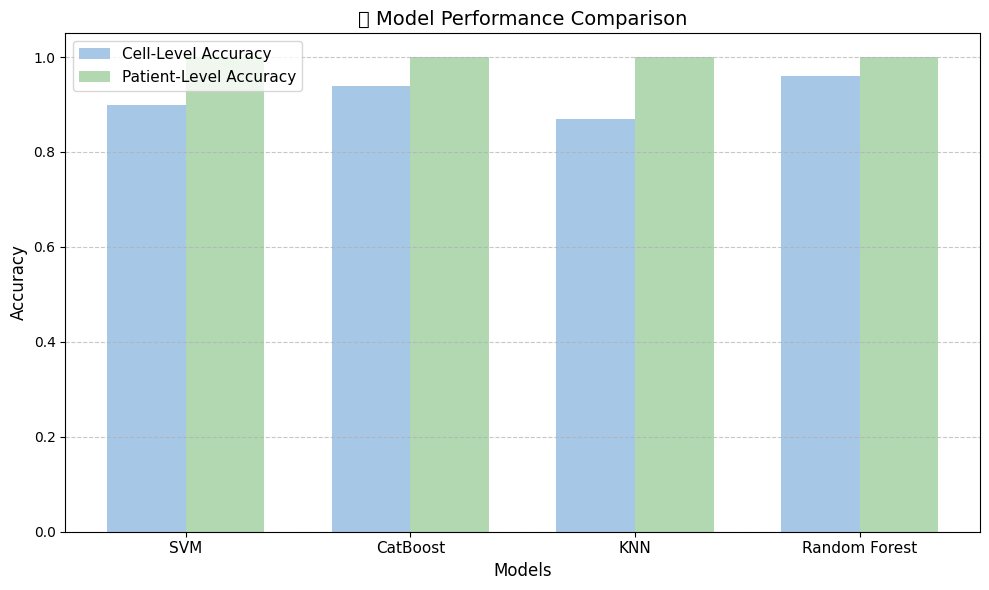

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Example accuracies (REPLACE these with your actual measured results!)
model_names = ['SVM', 'CatBoost', 'KNN', 'Random Forest']
cell_level_accuracies = [0.90, 0.94, 0.87, 0.96]     # Replace with your real values
patient_level_accuracies = [1.00, 1.00, 1.00, 1.00]  # Replace with your real values

x = np.arange(len(model_names))  # label locations
width = 0.35  # width of the bars

# Better pastel colors
pastel_blue = "#a7c7e7"  # Better brighter pastel blue
pastel_green = "#b2d8b2"

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, cell_level_accuracies, width, label='Cell-Level Accuracy', color=pastel_blue)
rects2 = ax.bar(x + width/2, patient_level_accuracies, width, label='Patient-Level Accuracy', color=pastel_green)

# Labels, title and custom x-axis tick labels
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Models', fontsize=12)
ax.set_title('📊 Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)

plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Light horizontal grid
plt.tight_layout()
plt.show()

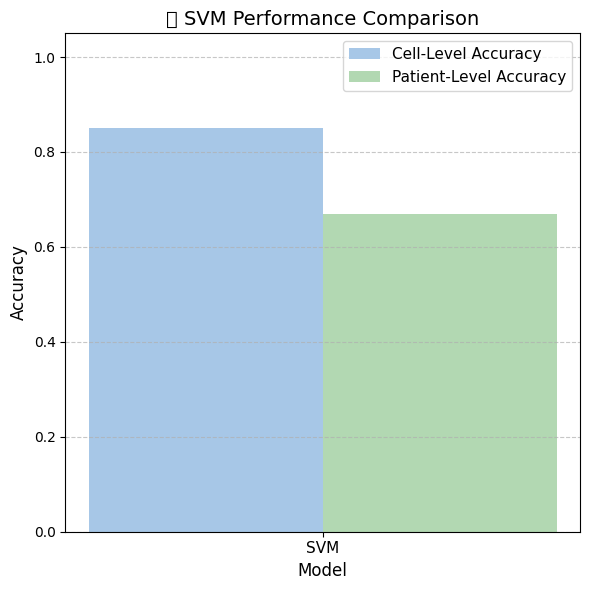

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Only one model: SVM
model_names = ['SVM']
cell_level_accuracies = [0.85]      # Your real result
patient_level_accuracies = [0.67]   # Your real result

x = np.arange(len(model_names))  # label locations
width = 0.35  # width of the bars

# Better pastel colors
pastel_blue = "#a7c7e7"  # Brighter pastel blue
pastel_green = "#b2d8b2"

fig, ax = plt.subplots(figsize=(6,6))
rects1 = ax.bar(x - width/2, cell_level_accuracies, width, label='Cell-Level Accuracy', color=pastel_blue)
rects2 = ax.bar(x + width/2, patient_level_accuracies, width, label='Patient-Level Accuracy', color=pastel_green)

# Labels, title and custom x-axis tick labels
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('📊 SVM Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)

plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Light horizontal grid
plt.tight_layout()
plt.show()

In [83]:
# Map sample_id to labels
sample_to_label = {
    "GSM4339769": "mild",
    "GSM4339770": "mild",
    "GSM4339771": "severe",
    "GSM4339772": "mild",
    "GSM4339773": "severe",
    "GSM4339774": "severe",
    "GSM4475048": "healthy",
    "GSM4475049": "healthy",
    "GSM4475050": "healthy",
    "GSM4475051": "severe",
    "GSM4475052": "severe",
    "GSM4475053": "severe",
}

# Assign labels based on sample_id
adata_combined.obs['label'] = adata_combined.obs['sample_id'].map(lambda x: sample_to_label.get(x.split("_")[0], "unknown"))

print(adata_combined.obs['label'].value_counts())  # Check labels

label
severe     52929
healthy    28056
mild        9710
Name: count, dtype: int64


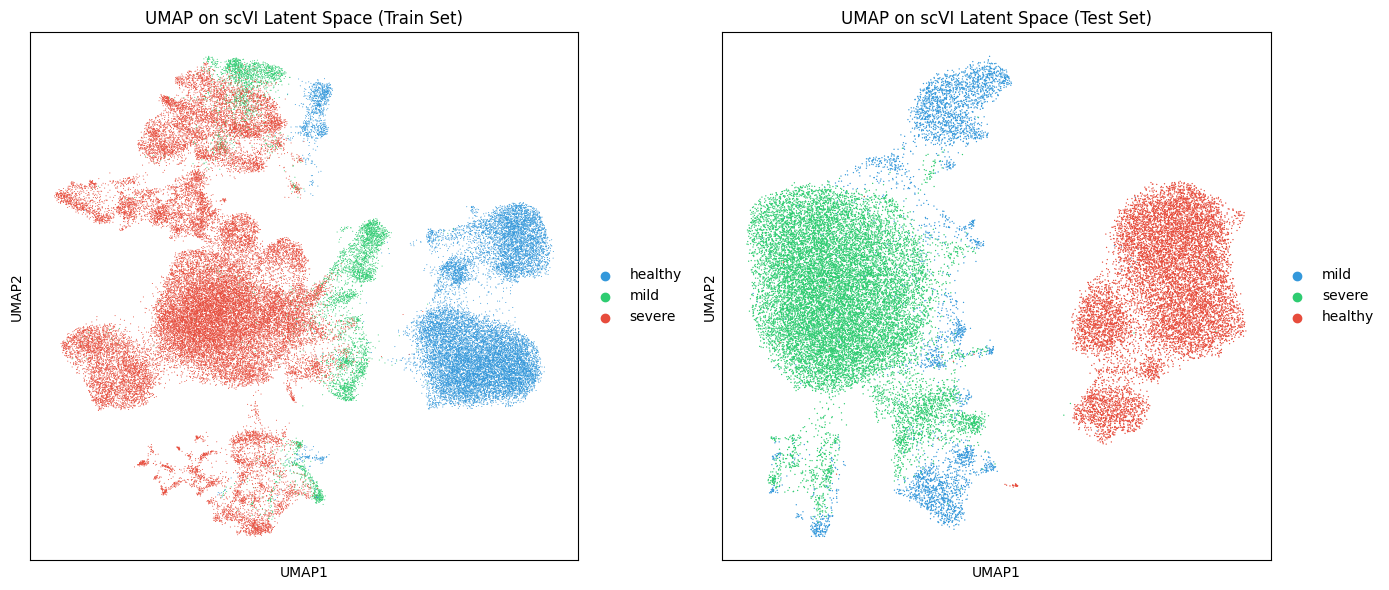

In [84]:
import scanpy as sc
import matplotlib.pyplot as plt

# Make sure you have scVI latents saved
adata_train.obsm['X_latent'] = adata_train.obsm['X_scVI']
adata_test.obsm['X_latent'] = adata_test.obsm['X_scVI']

# Compute neighbors and UMAP separately
sc.pp.neighbors(adata_train, use_rep='X_latent')
sc.tl.umap(adata_train)

sc.pp.neighbors(adata_test, use_rep='X_latent')
sc.tl.umap(adata_test)

# If labels not attached yet, attach them
adata_train.obs['label'] = adata_train.obs['sample_id'].map(lambda x: sample_to_label.get(x.split("_")[0], "unknown"))
adata_test.obs['label'] = adata_test.obs['sample_id'].map(lambda x: sample_to_label.get(x.split("_")[0], "unknown"))

# Now plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Train UMAP
sc.pl.umap(
    adata_train, 
    color='label', 
    ax=axs[0], 
    show=False, 
    title="UMAP on scVI Latent Space (Train Set)", 
    palette=['#3498db', '#2ecc71', '#e74c3c']
)

# Test UMAP
sc.pl.umap(
    adata_test, 
    color='label', 
    ax=axs[1], 
    show=False, 
    title="UMAP on scVI Latent Space (Test Set)", 
    palette=['#3498db', '#2ecc71', '#e74c3c']
)

plt.tight_layout()
plt.show()